# EvidenceLab #01: 95% Confidence Interval vs 95% Credible Interval
**Same data. Different frameworks. Different meaning.**

This Google Colab-ready tutorial uses simulated hypertension-trial data. **No external dataset, API key, or specialist Bayesian package is required.** Choose **Runtime → Run all** and every result, figure, and interpretation is generated automatically.

## Learning objectives
You will learn to:
1. Define a treatment effect.
2. Calculate and interpret a frequentist 95% confidence interval.
3. Understand prior, likelihood, posterior, and a 95% credible interval.
4. Observe confidence-interval coverage through repeated simulation.
5. Explore how priors and sample size affect uncertainty.

> All data are simulated for teaching and do not represent real patients or trial results.

## 1. What is a treatment effect?
Imagine a study comparing a new hypertension treatment with usual care.

The outcome is **change in systolic blood pressure (SBP)** from baseline, in mmHg.

Here, the **treatment effect** is:

**mean SBP change in treatment − mean SBP change in control**

A negative value favors treatment because it means SBP fell more in the treatment group. For example, −3 mmHg means the treatment group had, on average, a 3 mmHg greater BP reduction than the control group.

In real research the true population effect is unknown. In a simulation we choose it, which lets us test how statistical procedures behave.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

SEED = 20260909
rng = np.random.default_rng(SEED)

N_PER_GROUP = 45
TRUE_EFFECT = -3.0
CONTROL_MEAN = 0.0
OUTCOME_SD = 10.0

print("Setup complete.")
print(f"True simulated treatment effect: {TRUE_EFFECT:.1f} mmHg")

Setup complete.
True simulated treatment effect: -3.0 mmHg


## 2. Generate one simulated study
Random samples vary, so the observed effect will usually differ from the true effect.

In [2]:
control = rng.normal(CONTROL_MEAN, OUTCOME_SD, N_PER_GROUP)
treatment = rng.normal(CONTROL_MEAN + TRUE_EFFECT, OUTCOME_SD, N_PER_GROUP)

df = pd.DataFrame({"group":["Control"]*N_PER_GROUP+["Treatment"]*N_PER_GROUP,
                   "sbp_change_mmHg":np.r_[control,treatment]})
display(df.groupby("group")["sbp_change_mmHg"].agg(["count","mean","std"]).round(2))

observed_effect=treatment.mean()-control.mean()
direction="lower" if observed_effect < 0 else "higher"
print(f"Observed treatment effect: {observed_effect:.2f} mmHg")
print(f"The treatment group's average SBP change was {abs(observed_effect):.2f} mmHg {direction} than control.")

,count,mean,std
group,,,
Control,45,0.55,9.47
Treatment,45,-1.15,11.64


Observed treatment effect: -1.70 mmHg
The treatment group's average SBP change was 1.70 mmHg lower than control.


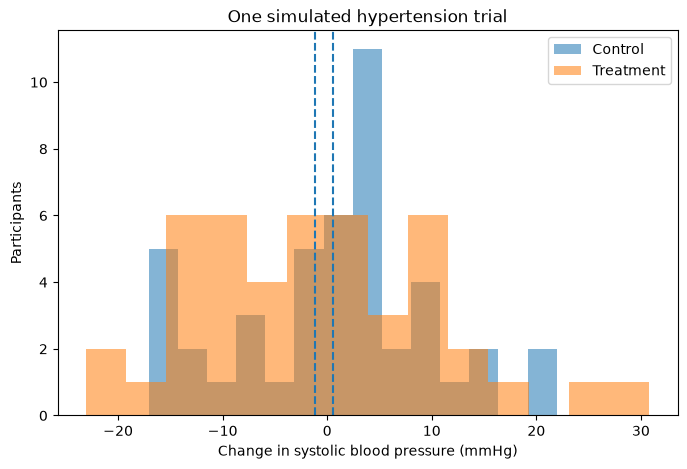

In [3]:
fig,ax=plt.subplots(figsize=(8,5))
ax.hist(control,bins=14,alpha=.55,label="Control")
ax.hist(treatment,bins=14,alpha=.55,label="Treatment")
ax.axvline(control.mean(),linestyle="--")
ax.axvline(treatment.mean(),linestyle="--")
ax.set(xlabel="Change in systolic blood pressure (mmHg)",ylabel="Participants",
       title="One simulated hypertension trial")
ax.legend(); plt.show()

## 3. Frequentist 95% confidence interval
A **95% confidence interval** comes from a procedure that, under repeated sampling and the model assumptions, would contain the true parameter in approximately 95% of repeated studies.

It does **not** mean there is a 95% probability that the fixed true effect lies inside this particular observed interval.

In [4]:
def welch_ci(x,y,confidence=.95):
    nx,ny=len(x),len(y)
    mx,my=np.mean(x),np.mean(y)
    vx,vy=np.var(x,ddof=1),np.var(y,ddof=1)
    effect=mx-my
    se=np.sqrt(vx/nx+vy/ny)
    dof=(vx/nx+vy/ny)**2/((vx/nx)**2/(nx-1)+(vy/ny)**2/(ny-1))
    crit=stats.t.ppf(1-(1-confidence)/2,dof)
    return effect,effect-crit*se,effect+crit*se,se,dof

effect,ci_low,ci_high,se,dof=welch_ci(treatment,control)
print(f"Estimated effect: {effect:.2f} mmHg")
print(f"95% CI: [{ci_low:.2f}, {ci_high:.2f}] mmHg")
if ci_low <= 0 <= ci_high:
    print("Zero is inside the interval. At the conventional two-sided 5% level, the data do not rule out a zero mean difference.")
else:
    print("Zero is outside the interval. At the conventional two-sided 5% level, the data are incompatible with a zero mean difference under this model.")

Estimated effect: -1.70 mmHg
95% CI: [-6.15, 2.74] mmHg
Zero is inside the interval. At the conventional two-sided 5% level, the data do not rule out a zero mean difference.


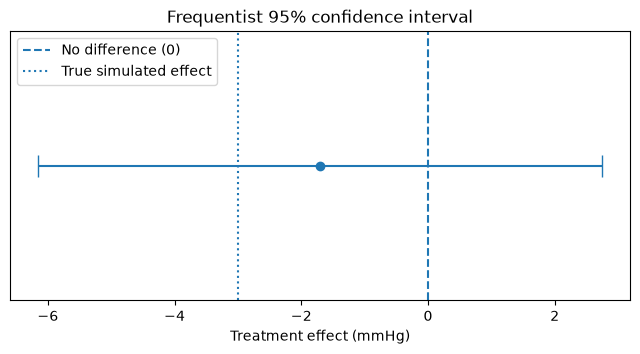

In [5]:
fig,ax=plt.subplots(figsize=(8,3.5))
ax.errorbar(effect,0,xerr=[[effect-ci_low],[ci_high-effect]],fmt="o",capsize=8)
ax.axvline(0,linestyle="--",label="No difference (0)")
ax.axvline(TRUE_EFFECT,linestyle=":",label="True simulated effect")
ax.set_yticks([]); ax.set_xlabel("Treatment effect (mmHg)")
ax.set_title("Frequentist 95% confidence interval"); ax.legend(); plt.show()

## 4. Watch 95% coverage emerge
Because we generated the population, we know the true effect. We now repeat the study **1,000 times**, build a 95% CI each time, and count how often the interval contains the true effect.

In [6]:
N_SIMULATIONS=1000
sim_rng=np.random.default_rng(SEED+1)
records=[]
for i in range(N_SIMULATIONS):
    c=sim_rng.normal(CONTROL_MEAN,OUTCOME_SD,N_PER_GROUP)
    t=sim_rng.normal(CONTROL_MEAN+TRUE_EFFECT,OUTCOME_SD,N_PER_GROUP)
    est,lo,hi,_,_=welch_ci(t,c)
    records.append((i+1,est,lo,hi,lo<=TRUE_EFFECT<=hi))
coverage=pd.DataFrame(records,columns=["study","estimate","lower","upper","covers_truth"])
rate=coverage.covers_truth.mean()
print(f"Studies: {N_SIMULATIONS:,}")
print(f"Intervals containing truth: {coverage.covers_truth.sum():,}")
print(f"Observed coverage: {100*rate:.1f}%")
print("This illustrates long-run coverage. The exact simulated percentage varies around 95%.")

Studies: 1,000
Intervals containing truth: 952
Observed coverage: 95.2%
This illustrates long-run coverage. The exact simulated percentage varies around 95%.


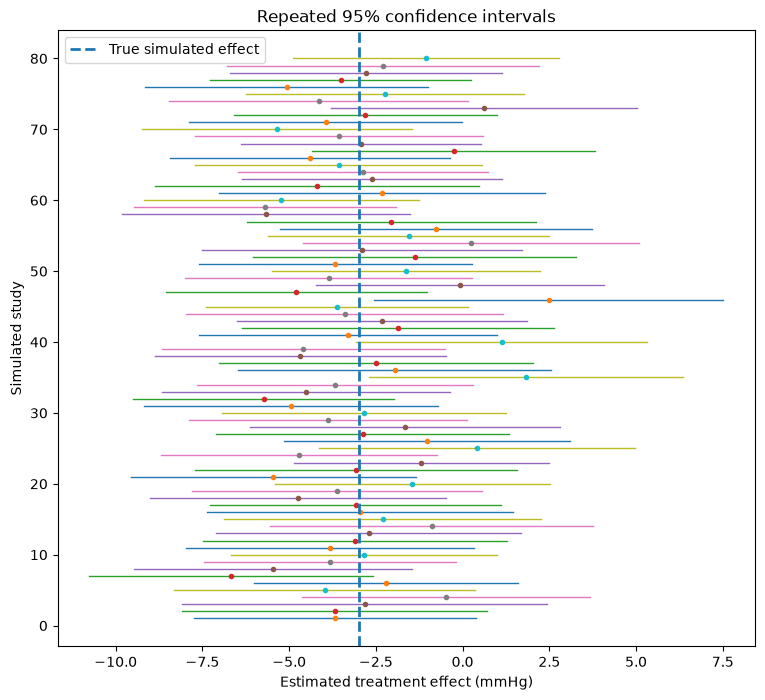

In [7]:
p=coverage.head(80)
fig,ax=plt.subplots(figsize=(9,8))
for _,r in p.iterrows():
    ax.plot([r.lower,r.upper],[r.study,r.study],linewidth=1)
    ax.plot(r.estimate,r.study,"o",markersize=3)
ax.axvline(TRUE_EFFECT,linestyle="--",linewidth=2,label="True simulated effect")
ax.set(xlabel="Estimated treatment effect (mmHg)",ylabel="Simulated study",
       title="Repeated 95% confidence intervals")
ax.legend(); plt.show()

## 5. Bayesian inference: prior + data → posterior
Bayesian inference represents uncertainty about the unknown parameter using probability distributions.

**Prior:** uncertainty about plausible treatment effects before incorporating the current study.

**Likelihood:** how compatible different parameter values are with the observed data under the model.

**Posterior:** updated uncertainty after combining prior and data.

For transparency, this tutorial uses a normal approximation for the estimated mean difference and a normal prior, so no specialized Bayesian package is needed.

In [8]:
PRIOR_MEAN=0.0
PRIOR_SD=10.0  # broad, zero-centered teaching prior on this scale

likelihood_var=se**2
prior_var=PRIOR_SD**2
posterior_var=1/(1/prior_var+1/likelihood_var)
posterior_sd=np.sqrt(posterior_var)
posterior_mean=posterior_var*(PRIOR_MEAN/prior_var+effect/likelihood_var)

z=stats.norm.ppf(.975)
cr_low=posterior_mean-z*posterior_sd
cr_high=posterior_mean+z*posterior_sd
prob_benefit=stats.norm.cdf((0-posterior_mean)/posterior_sd)

print(f"Prior: Normal({PRIOR_MEAN:.1f}, {PRIOR_SD:.1f}²)")
print(f"Posterior mean: {posterior_mean:.2f} mmHg")
print(f"95% credible interval: [{cr_low:.2f}, {cr_high:.2f}] mmHg")
print(f"P(treatment effect < 0 | model, prior, data) = {100*prob_benefit:.1f}%")
print("Interpretation: conditional on this model, prior, and observed data, 95% of posterior probability lies within the credible interval.")

Prior: Normal(0.0, 10.0²)
Posterior mean: -1.62 mmHg
95% credible interval: [-5.90, 2.66] mmHg
P(treatment effect < 0 | model, prior, data) = 77.1%
Interpretation: conditional on this model, prior, and observed data, 95% of posterior probability lies within the credible interval.


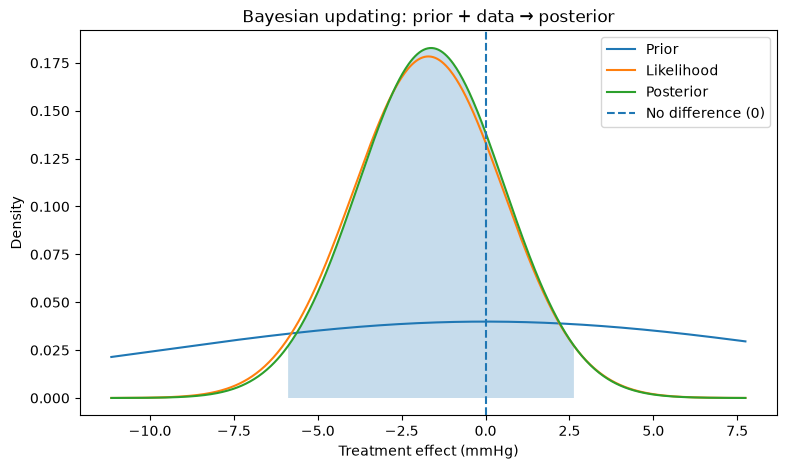

In [9]:
grid=np.linspace(min(ci_low,cr_low)-5,max(ci_high,cr_high)+5,600)
prior_pdf=stats.norm.pdf(grid,PRIOR_MEAN,PRIOR_SD)
lik_pdf=stats.norm.pdf(grid,effect,se)
post_pdf=stats.norm.pdf(grid,posterior_mean,posterior_sd)
fig,ax=plt.subplots(figsize=(9,5))
ax.plot(grid,prior_pdf,label="Prior")
ax.plot(grid,lik_pdf,label="Likelihood")
ax.plot(grid,post_pdf,label="Posterior")
ax.fill_between(grid,0,post_pdf,where=(grid>=cr_low)&(grid<=cr_high),alpha=.25)
ax.axvline(0,linestyle="--",label="No difference (0)")
ax.set(xlabel="Treatment effect (mmHg)",ylabel="Density",title="Bayesian updating: prior + data → posterior")
ax.legend(); plt.show()

## 6. Why the distinction can matter
With a weak prior and informative data, a CI and credible interval may be numerically similar. Their **meaning still differs**.

With smaller samples or informative priors, the summaries may diverge more. A conventional frequentist test can fail to reject a zero effect while a Bayesian analysis assigns substantial posterior probability to benefit. This is not a contradiction. The frameworks answer different questions, and the Bayesian statement is conditional on the chosen model and prior.

In [10]:
comparison=pd.DataFrame({
"Question":["Framework","Parameter treatment","Main uncertainty","Requires prior?","Meaning of 95%","Probability statement for this interval?"],
"95% Confidence Interval":["Frequentist","Fixed but unknown","Sampling variability","No","Long-run coverage of procedure","No"],
"95% Credible Interval":["Bayesian","Uncertainty represented probabilistically","Posterior uncertainty","Yes","95% of posterior probability","Yes, conditional on model, prior, and data"]})
display(comparison)

,Question,95% Confidence Interval,95% Credible Interval
0,Framework,Frequentist,Bayesian
1,Parameter treatment,Fixed but unknown,Uncertainty represented probabilistically
2,Main uncertainty,Sampling variability,Posterior uncertainty
3,Requires prior?,No,Yes
4,Meaning of 95%,Long-run coverage of procedure,95% of posterior probability
5,Probability statement for this interval?,No,"Yes, conditional on model, prior, and data"


## 7. Prior sensitivity
Keep the same data and change the prior. This demonstrates sensitivity, not permission to choose a prior after seeing which answer you prefer. Priors should be scientifically defensible and transparently reported.

In [11]:
priors=[("Weak N(0,10²)",0.,10.),("Skeptical N(0,3²)",0.,3.),("Informative N(-4,2²)",-4.,2.)]
rows=[]
for name,pm,psd in priors:
    pv=psd**2
    pv_post=1/(1/pv+1/likelihood_var)
    sd_post=np.sqrt(pv_post)
    m_post=pv_post*(pm/pv+effect/likelihood_var)
    lo,hi=m_post-z*sd_post,m_post+z*sd_post
    pb=stats.norm.cdf((0-m_post)/sd_post)
    rows.append([name,m_post,lo,hi,pb])
prior_results=pd.DataFrame(rows,columns=["Prior","Posterior mean","Lower 95%","Upper 95%","P(effect < 0)"])
display(prior_results.round(3))

,Prior,Posterior mean,Lower 95%,Upper 95%,P(effect < 0)
0,"Weak N(0,10²)",-1.623,-5.901,2.655,0.771
1,"Skeptical N(0,3²)",-1.095,-4.610,2.419,0.729
2,"Informative N(-4,2²)",-2.980,-5.902,-0.058,0.977


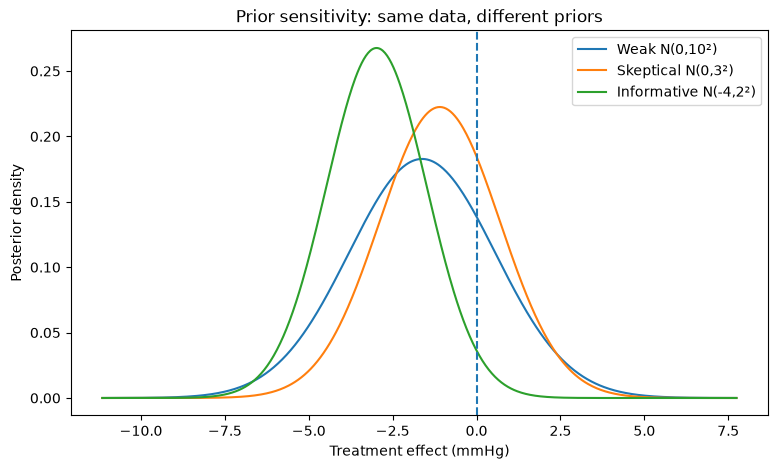

In [12]:
fig,ax=plt.subplots(figsize=(9,5))
for name,pm,psd in priors:
    pv=psd**2
    pv_post=1/(1/pv+1/likelihood_var)
    sd_post=np.sqrt(pv_post)
    m_post=pv_post*(pm/pv+effect/likelihood_var)
    ax.plot(grid,stats.norm.pdf(grid,m_post,sd_post),label=name)
ax.axvline(0,linestyle="--")
ax.set(xlabel="Treatment effect (mmHg)",ylabel="Posterior density",
       title="Prior sensitivity: same data, different priors")
ax.legend(); plt.show()

## 8. Sample size and uncertainty
More information generally narrows uncertainty. This illustration compares expected interval widths for several sample sizes. It is **not** a substitute for a formal study-specific sample-size calculation.

In [13]:
sizes=[20,50,100,500]
rows=[]
for n in sizes:
    approx_se=OUTCOME_SD*np.sqrt(2/n)
    ci_width=2*z*approx_se
    pv=PRIOR_SD**2
    post_var=1/(1/pv+1/approx_se**2)
    cr_width=2*z*np.sqrt(post_var)
    rows.append([n,approx_se,ci_width,cr_width])
size_results=pd.DataFrame(rows,columns=["Participants/group","Approx. SE","Approx. 95% CI width","Approx. 95% CrI width"])
display(size_results.round(2))

,Participants/group,Approx. SE,Approx. 95% CI width,Approx. 95% CrI width
0,20,3.16,12.40,11.82
1,50,2.00,7.84,7.69
2,100,1.41,5.54,5.49
3,500,0.63,2.48,2.47


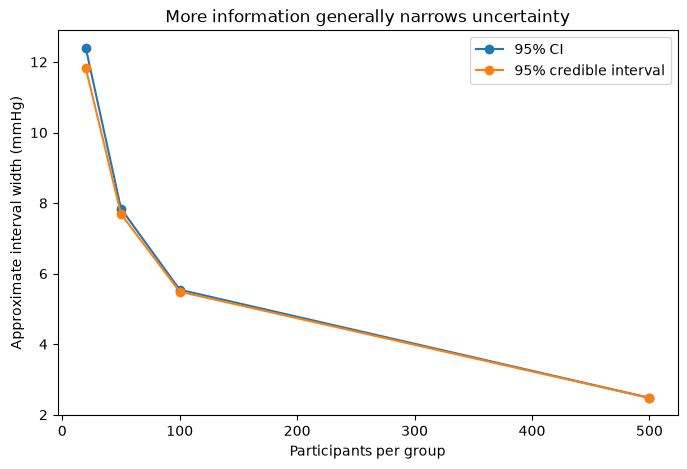

In [14]:
fig,ax=plt.subplots(figsize=(8,5))
ax.plot(size_results["Participants/group"],size_results["Approx. 95% CI width"],marker="o",label="95% CI")
ax.plot(size_results["Participants/group"],size_results["Approx. 95% CrI width"],marker="o",label="95% credible interval")
ax.set(xlabel="Participants per group",ylabel="Approximate interval width (mmHg)",
       title="More information generally narrows uncertainty")
ax.legend(); plt.show()

## 9. What does this mean for a public health decision-maker?

You do not need to memorize the equations to use interval estimates responsibly.

The key question is: **what uncertainty statement does the analysis actually allow you to make?**

- A confidence interval summarizes uncertainty through a procedure with a known long-run coverage property.
- A Bayesian analysis can make probability statements about the unknown effect, conditional on the statistical model, prior, and observed data.
- Neither framework automatically tells you whether to adopt a program or treatment. Decisions also depend on the **size of the benefit, harms, costs, feasibility, equity, and the consequences of being wrong**.

A useful Bayesian question is therefore not only, “Is there any probability of benefit?” but also, **“What is the probability that the benefit is large enough to matter?”**

In [15]:
# Decision-relevant posterior probabilities
# Negative values favor treatment in this tutorial.
CLINICALLY_RELEVANT_THRESHOLD = -2.0  # example teaching threshold, in mmHg

prob_any_benefit = stats.norm.cdf((0 - posterior_mean) / posterior_sd)
prob_relevant_benefit = stats.norm.cdf(
    (CLINICALLY_RELEVANT_THRESHOLD - posterior_mean) / posterior_sd
)

print(f"P(any benefit: effect < 0 | model, prior, data) = {100*prob_any_benefit:.1f}%")
print(
    f"P(effect < {CLINICALLY_RELEVANT_THRESHOLD:.1f} mmHg | model, prior, data) "
    f"= {100*prob_relevant_benefit:.1f}%"
)
print()
print(
    "The -2 mmHg threshold is used only as a teaching example. "
    "A real decision threshold should be prespecified and clinically justified."
)

P(any benefit: effect < 0 | model, prior, data) = 77.1%
P(effect < -2.0 mmHg | model, prior, data) = 43.1%

The -2 mmHg threshold is used only as a teaching example. A real decision threshold should be prespecified and clinically justified.


# Take-home message
## Same 95%. Different meaning.

**Confidence interval:** 95% describes the long-run coverage of the interval-generating procedure under repeated sampling and the model assumptions.

**Credible interval:** 95% describes posterior probability for the parameter, conditional on the specified Bayesian model, prior, and observed data.

Neither framework eliminates uncertainty. They formalize it differently.

### Try it yourself
Change `N_PER_GROUP`, `TRUE_EFFECT`, or `PRIOR_SD` near the top, then choose **Runtime → Run all** again.

**EvidenceLab | See it. Understand it. Run it.**

Created by **Dr. Amobi Andrew Onovo, PhD, MPH**  
Epidemiology | Data Science | AI for Global Health